In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [154]:
df_spy = pd.read_parquet('../data/raw/TRTH/equity/US/bbo/SPY.P/2009-01-02-SPY.P-bbo.parquet')
df_spy.head()

,xltime,bid-price,bid-volume,ask-price,ask-volume
0,39815.385416,80.21,2,92.43,1
1,39815.385418,89.44,10,90.01,2
2,39815.386410,89.44,10,89.99,1
3,39815.406541,89.45,1,89.99,1
4,39815.410057,89.45,1,90.01,2


In [155]:
df_aapl = pd.read_parquet('../data/raw/TRTH/equity/US/bbo/AAPL.OQ/2009-01-02-AAPL.OQ-bbo.parquet')
df_aapl.head()

,xltime,bid-price,bid-volume,ask-price,ask-volume
0,39815.500004,0.00,0,200.00,2
1,39815.500848,85.20,1,200.00,2
2,39815.502450,85.20,1,86.48,1
3,39815.502679,80.00,1,86.48,1
4,39815.502703,85.35,1,86.48,1


In [156]:
df_spy = df_spy.rename(columns={
    "xltime": "timestamp",
    "trade-price": "price",
    "trade-volume": "volume",
    "trade-stringflag": "flags",
    "trade-rawflag": "rawflag"
})

df_spy['timestamp'] = pd.to_datetime(df_spy['timestamp'], unit='D', origin='1899-12-30')
df_spy = df_spy.set_index('timestamp')
df_spy['mid-price'] = (df_spy['bid-price'] + df_spy['ask-price']) / 2
df_spy['mid-price-return'] = df_spy['mid-price'].pct_change()
df_spy = df_spy[df_spy['mid-price-return'] != 0]
df_spy = df_spy.dropna()
df_spy.head()

,bid-price,bid-volume,ask-price,ask-volume,mid-price,mid-price-return
timestamp,,,,,,
2009-01-02 09:15:00.113999748,89.44,10,90.01,2,89.725,0.039446
2009-01-02 09:16:25.836000087,89.44,10,89.99,1,89.715,-0.000111
2009-01-02 09:45:25.130999900,89.45,1,89.99,1,89.720,0.000056
2009-01-02 09:50:28.898999957,89.45,1,90.01,2,89.730,0.000111
2009-01-02 10:01:56.735000163,89.50,8,90.01,2,89.755,0.000279


In [157]:
df_aapl = df_aapl.rename(columns={
    "xltime": "timestamp",
    "trade-price": "price",
    "trade-volume": "volume",
    "trade-stringflag": "flags",
    "trade-rawflag": "rawflag"
})

df_aapl['timestamp'] = pd.to_datetime(df_aapl['timestamp'], unit='D', origin='1899-12-30')
df_aapl = df_aapl.set_index('timestamp')
df_aapl['mid-price'] = (df_aapl['bid-price'] + df_aapl['ask-price']) / 2
df_aapl['mid-price-return'] = df_aapl['mid-price'].pct_change()
df_aapl = df_aapl[df_aapl['mid-price-return'] != 0]
df_aapl = df_aapl.dropna()
df_aapl.head()

,bid-price,bid-volume,ask-price,ask-volume,mid-price,mid-price-return
timestamp,,,,,,
2009-01-02 12:01:13.245000392,85.20,1,200.00,2,142.600,0.426000
2009-01-02 12:03:31.636999575,85.20,1,86.48,1,85.840,-0.398036
2009-01-02 12:03:51.488000202,80.00,1,86.48,1,83.240,-0.030289
2009-01-02 12:03:53.496999691,85.35,1,86.48,1,85.915,0.032136
2009-01-02 12:12:12.460000017,85.50,3,86.48,1,85.990,0.000873


In [158]:
merge_df = pd.merge(df_aapl.sort_index(), df_spy.sort_index(), left_index=True, right_index=True, how='outer', suffixes=('_aapl', '_spy'))
merge_df = merge_df.sort_index().ffill().bfill()
merge_df.head()

,bid-price_aapl,bid-volume_aapl,ask-price_aapl,ask-volume_aapl,mid-price_aapl,mid-price-return_aapl,bid-price_spy,bid-volume_spy,ask-price_spy,ask-volume_spy,mid-price_spy,mid-price-return_spy
timestamp,,,,,,,,,,,,
2009-01-02 09:15:00.113999748,85.2,1.0,200.0,2.0,142.6,0.426,89.44,10.0,90.01,2.0,89.725,0.039446
2009-01-02 09:16:25.836000087,85.2,1.0,200.0,2.0,142.6,0.426,89.44,10.0,89.99,1.0,89.715,-0.000111
2009-01-02 09:45:25.130999900,85.2,1.0,200.0,2.0,142.6,0.426,89.45,1.0,89.99,1.0,89.720,0.000056
2009-01-02 09:50:28.898999957,85.2,1.0,200.0,2.0,142.6,0.426,89.45,1.0,90.01,2.0,89.730,0.000111
2009-01-02 10:01:56.735000163,85.2,1.0,200.0,2.0,142.6,0.426,89.50,8.0,90.01,2.0,89.755,0.000279


Task Slide 61

In [159]:
merge_df['product_mid_price_return'] = merge_df['mid-price-return_aapl'] * merge_df['mid-price-return_spy']
average = merge_df['product_mid_price_return'].mean()
std_mid_price_ret_spy = merge_df['mid-price-return_spy'].std()
std_mid_price_ret_aapl = merge_df['mid-price-return_aapl'].std()

correlation = average / (std_mid_price_ret_spy * std_mid_price_ret_aapl)
print("Correlation between AAPL and SPY mid-price returns:", correlation)

Correlation between AAPL and SPY mid-price returns: 0.025898396158613366


In [160]:
N = 100
T = 365
sigma = 0.2

np.random.seed(42)
R = np.random.normal(0, sigma**2, (N, T))

C_est = np.corrcoef(R)
print(f"Shape of the estimated correlation matrix: {C_est.shape}")
print(f" Here is the first 5x5 block:\n{C_est[:5, :5]}")


Shape of the estimated correlation matrix: (100, 100)
 Here is the first 5x5 block:
[[ 1.         -0.05377056  0.08865355  0.01465569 -0.02673042]
 [-0.05377056  1.          0.06367517  0.06331467 -0.02856667]
 [ 0.08865355  0.06367517  1.         -0.07651215  0.0371445 ]
 [ 0.01465569  0.06331467 -0.07651215  1.         -0.05273072]
 [-0.02673042 -0.02856667  0.0371445  -0.05273072  1.        ]]


In [161]:
eigenval, eigenvect = np.linalg.eig(C_est)
eigenval = np.sort(eigenval)[::-1]

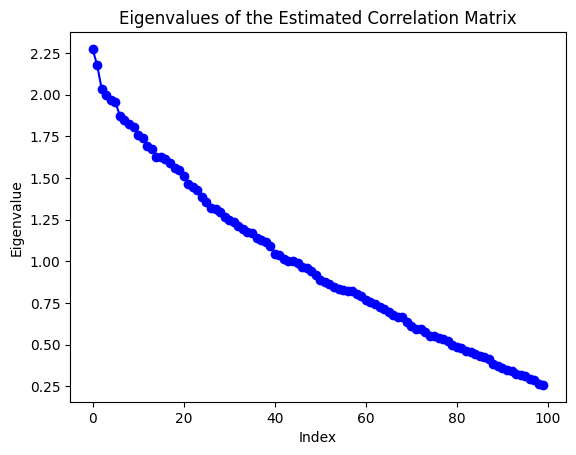

In [162]:
plt.plot(eigenval, marker='o', color='blue')
plt.title("Eigenvalues of the Estimated Correlation Matrix")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.show()

In [163]:
bins = 30
hist, edges = np.histogram(eigenval, bins=bins, density=True)
centers = (edges[:-1] + edges[1:]) / 2

In [164]:
def mp_pdf(lam, Q):
    lam_min = (1 - np.sqrt(Q))**2
    lam_max = (1 + np.sqrt(Q))**2
    pdf = np.zeros_like(lam)
    mask = (lam >= lam_min) & (lam <= lam_max)
    pdf[mask] = np.sqrt((lam_max - lam[mask]) * (lam[mask] - lam_min)) / (2 * np.pi * Q * lam[mask])
    return pdf

In [ ]:
def compare_MP(N, T, sigma):
    R = np.random.normal(0, sigma**2, (N, T))
    C_est = np.corrcoef(R)
    eigenval, _ = np.linalg.eig(C_est)
    eigenval = np.sort(eigenval)[::-1]
    bins = 30

    Q = N / T
    lam_min = (1 - np.sqrt(Q))**2
    lam_max = (1 + np.sqrt(Q))**2

    lam_grid = np.linspace( lam_min, lam_max , 100)

    plt.figure(figsize=(10,6))
    plt.hist(eigenval, bins=bins, density=True, color='blue', label='Empirical Eigenvalue Distribution')
    plt.plot(lam_grid, mp_pdf(lam_grid, Q), color='red', lw=2, label='Marčenko-Pastur PDF')
    plt.axvline(1, color='k', linestyle='--', label='True Eigenvalue')
    plt.title("Eigenvalue Distribution vs Marčenko-Pastur Law")
    plt.xlabel("Eigenvalue")
    plt.ylabel("Density")
    plt.legend()
    plt.show()
    return

In [ ]:
Q = N / T
lam_min = (1 - np.sqrt(Q))**2
lam_max = (1 + np.sqrt(Q))**2

lam_grid = np.linspace(lam_min, lam_max, 100)

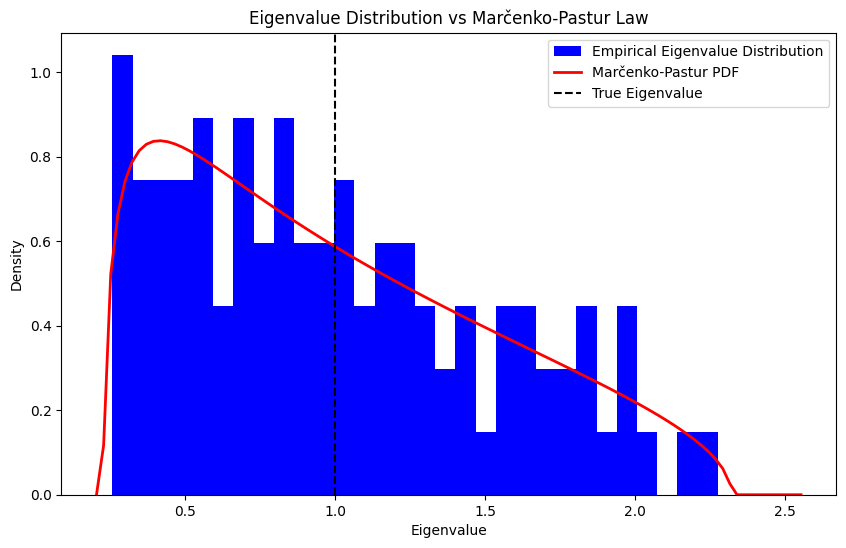

In [167]:
plt.figure(figsize=(10,6))
plt.hist(eigenval, bins=bins, density=True, color='blue', label='Empirical Eigenvalue Distribution')
plt.plot(lam_grid, mp_pdf(lam_grid, Q), color='red', lw=2, label='Marčenko-Pastur PDF')
plt.axvline(1, color='k', linestyle='--', label='True Eigenvalue')
plt.title("Eigenvalue Distribution vs Marčenko-Pastur Law")
plt.xlabel("Eigenvalue")
plt.ylabel("Density")
plt.legend()
plt.show()

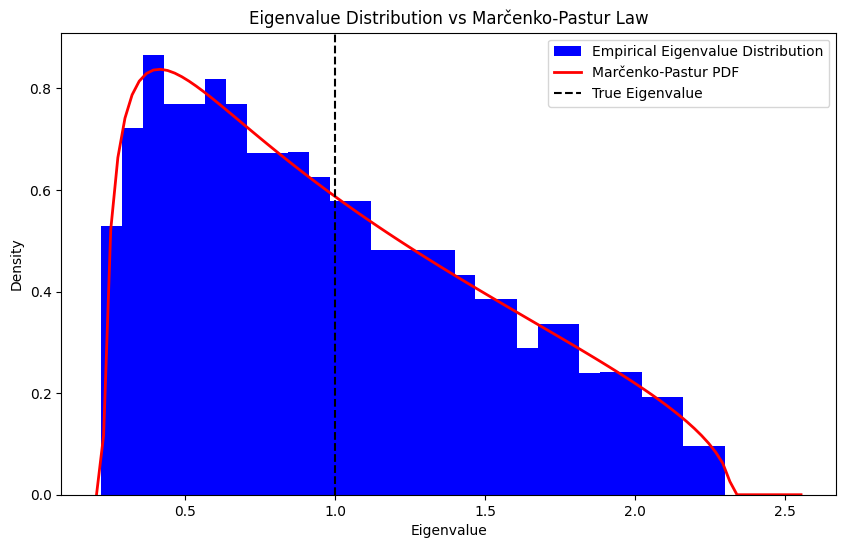

In [168]:
N = 300
T = 3*365
sigma = 0.2
compare_MP(N, T, sigma)

Task slide 62

In [171]:
N = 100
T = 365
sigma = 0.2

R = np.random.normal(0, sigma**2, (N, T))
C = np.corrcoef(R)
eigenval, _ = np.linalg.eig(C)

Q = N / T
lambda_max = (1 + np.sqrt(Q))**2
delta = np.array([eigen for eigen in eigenval if eigen > lambda_max]).mean()
eigenval_clipped = np.where(eigenval > lambda_max, delta, eigenval)

C:\Users\raphe\AppData\Local\Temp\ipykernel_6848\1631835991.py:11: RuntimeWarning: Mean of empty slice.
  delta = np.array([eigen for eigen in eigenval if eigen > lambda_max]).mean()
c:\Users\raphe\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
